<a href="https://colab.research.google.com/github/dohaalnabahin/Data_science_and_machine_learning_Journey/blob/main/Overall_Workflow.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#**Import libraries and Custom Functions**

In [24]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import statsmodels.api as sm
import statsmodels.tsa.api as tsa
import pmdarima as pm
from pmdarima.arima.utils import ndiffs, nsdiffs
from pmdarima.model_selection import train_test_split
import pmdarima as pm
plt.rcParams['figure.figsize']=(12,3)

#**Load and Explore Data**

In [ ]:
## Load the data
fname =''
df = pd.read_csv(fname,
                 # use args below if know datetime column already
#                 parse_dates=[''], index_col=""
                )
df

In [ ]:
# make sure index is datetime index

#**Define Time Series for Modeling**

In [ ]:
# Select time series to model.
col = '' # if a dataframe
ts = df[col]
ts

#**Set Frequency**

In [ ]:
# check frequency
ts.index

In [ ]:
# resample to desired frequency
# ts = ts.resample(...)..agg()
# ts

#**Visualize Time Series**

In [ ]:
# Visualize selected time series
ax = ts.plot()

#**Handle Missing Values**

In [ ]:
# Check for null values
ts.isna().sum()
copy
## Impute null values (if any)
# ts = ts.fillna(0)
# ts = ts.interpolate()
# ts = ts.fillna(method='ffill')
# ts = ts.fillna(method='bfill')

#**Determine if a seasonal or non-seasonal model is appropriate for the data**

In [ ]:
## Use Seasonal Decompose to check for seasonality
decomp = tsa.seasonal_decompose(ts)
fig = decomp.plot()
fig.set_size_inches(9, 5)
fig.tight_layout()


In [ ]:
# How big is the seasonal component
seasonal_delta = decomp.seasonal.max() - decomp.seasonal.min()

# How big is the seasonal component relative to the time series?
print(f"The seasonal component is {seasonal_delta} which is ~{seasonal_delta/(ts.max()-ts.min()) * 100 :.2f}% of the variation in time series.")

In [ ]:
# zooming in on smaller time period to see length of season
# decomp.seasonal.loc["...":].plot();

#**Check Stationarity and determine differencing (d and D)**

In [ ]:
# Check for stationarity
get_adfuller_results(ts)copy
Or Programmatically determine d and D

In [ ]:
# Determine differencing
d = ndiffs(ts)
print(f'd is {d}')
D = nsdiffs(ts, m = _)
print(f'D is {D}')
copy
Apply the differencing

In [ ]:
# For example, one non seasonal differencing
ts_diff = ts.diff().dropna()

#**Check Autocorrelation and Partial Autocorrelation to determine initial orders**

In [ ]:
plot_acf_pacf(ts_diff, annotate_seas=True, m = _);

#**Split into Training and Test Sets**

In [ ]:
from pmdarima.model_selection import train_test_split
train, test = train_test_split(ts, test_size=___)

## Visualize train-test-split
ax = train.plot(label="train")
test.plot(label="test")
ax.legend();

#**Define the Time Series Model Orders and Fit the model to the training data**

In [ ]:
# Orders for non seasonal components
p = _  # nonseasonal AR
d = _  # nonseasonal differencing
q = _ # nonseasonal MA

# Orders for seasonal components (if seasonal model)
P = _  # Seasonal AR
D = _  # Seasonal differencing
Q = _  # Seasonal MA
m = _ # Seasonal period

sarima = tsa.ARIMA(train, order = (p,d,q), seasonal_order=(P,D,Q,m)).fit()

In [ ]:
# Obtain summary
sarima.summary()


In [ ]:
# Obtain diagnostic plots
fig = sarima.plot_diagnostics()
fig.set_size_inches(10,6)
fig.tight_layout()

#**Generate and Visualize Forecasts**

In [ ]:
# Obtain summary of forecast as dataframe
forecast_df = sarima.get_forecast(len(test)).summary_frame()
# Plot the forecast with true values
plot_forecast(train, test, forecast_df, n_train_lags = 50)

#**Evaluate Model Performance**

In [ ]:
regression_metrics_ts(test, forecast_df["forecast"])

#**Iterate as Needed**

##Grid Search Orders with pmdarima

In [ ]:
import pmdarima as pm
# Default auto_arima will select model based on AIC score
auto_model = pm.auto_arima(
    train,
    seasonal=___,  # True or False
    m=____,  # if seasonal
    trace=True
)

#**Fit Statsmodels SARIMA Model Using the Parameters from auto_arima**

In [ ]:
# Try auto_arima orders
sarima = tsa.ARIMA(train, order = auto_model.order, seasonal_order=auto_model.seasonal_order).fit()

# Obtain summary
sarima.summary()

#**Select and justify the final model**

#**Fit a final model on the entire time series**

In [ ]:
final_p = "?"
final_q = "?"
final_d = "?"
final_P = "?"
final_Q = "?"
final_D = "?"

final_model = tsa.ARIMA(
    ts,
    order=(final_p, final_d, final_q),
    seasonal_order=(final_P, final_D, final_Q, m),
).fit()

#**Generate and Visualize Future Forecasts**

In [ ]:
# Ger forecast into true future (fit on entrie time series)
forecast_df = final_model.get_forecast(len(test)).summary_frame()

plot_forecast(train, test, forecast_df, n_train_lags = 20);

#**Calculate Summary Metrics for Stakeholder (Optional)**

In [ ]:
# Define starting and final values
starting_value = forecast_df['mean'].iloc[0]
final_value = forecast_df['mean'].iloc[-1]
# Change in x
delta = final_value - starting_value
print(f'The change in X over the forecast is {delta: .2f}.')
perc_change = (delta/starting_value) *100
print (f'The percentage change is {perc_change :.2f}%.')

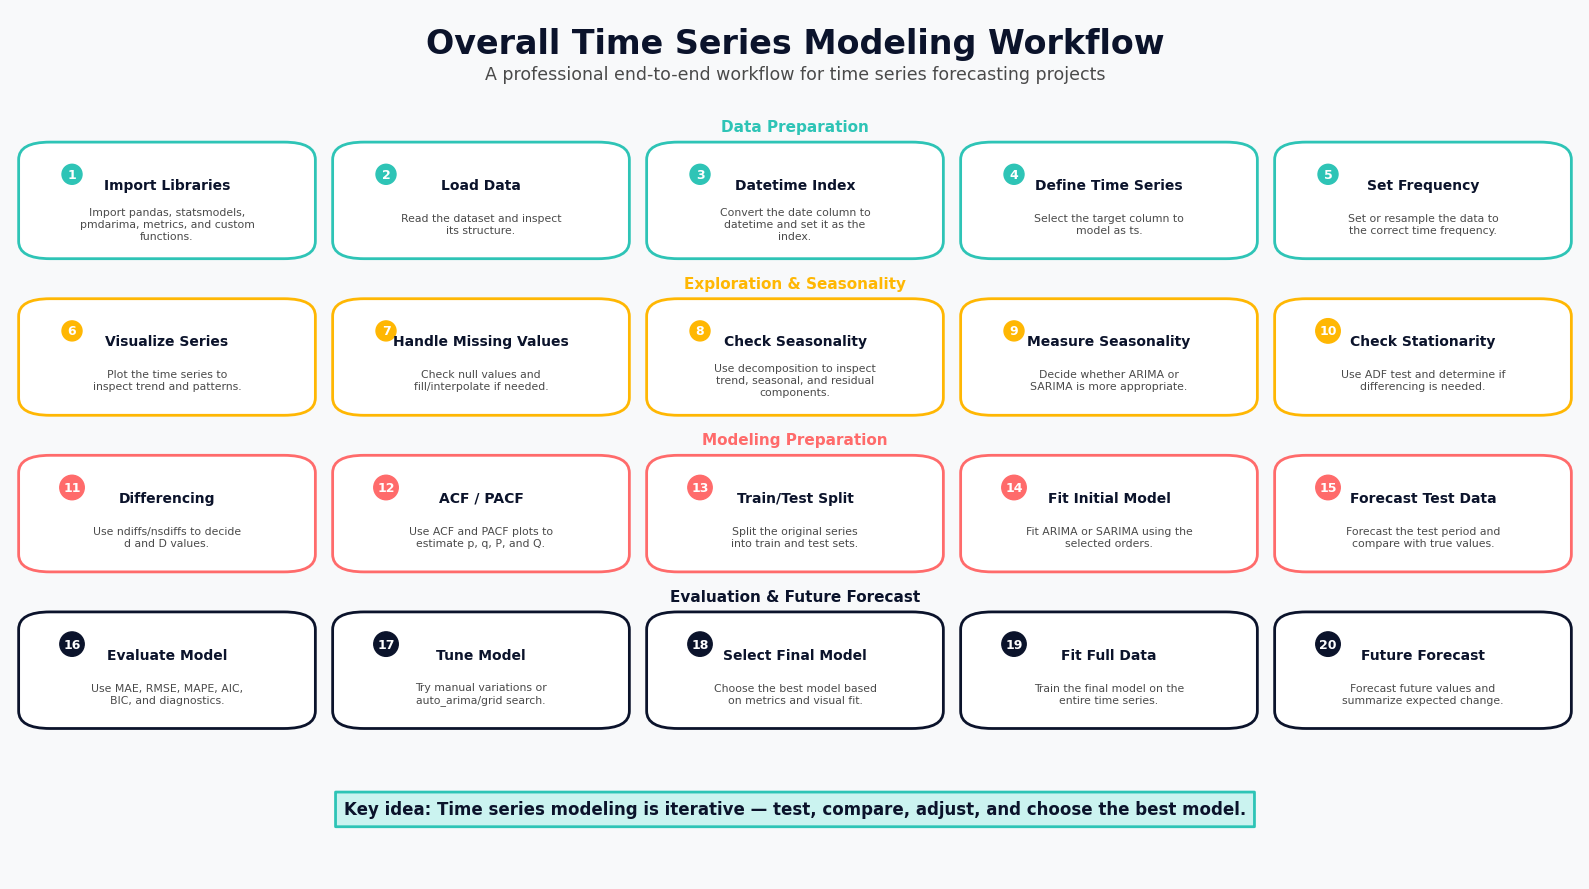

In [26]:
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch
import textwrap

# Professional color palette
NAVY = "#0B132B"
TEAL = "#2EC4B6"
LIGHT_TEAL = "#CBF3F0"
CORAL = "#FF6B6B"
GOLD = "#FFB703"
GRAY = "#4A4A4A"
LIGHT_BG = "#F8F9FA"
WHITE = "#FFFFFF"

fig, ax = plt.subplots(figsize=(16, 9))
fig.patch.set_facecolor(LIGHT_BG)
ax.set_facecolor(LIGHT_BG)
ax.axis("off")

# Title
ax.text(
    0.5, 0.96,
    "Overall Time Series Modeling Workflow",
    ha="center",
    va="center",
    fontsize=24,
    fontweight="bold",
    color=NAVY
)

ax.text(
    0.5, 0.925,
    "A professional end-to-end workflow for time series forecasting projects",
    ha="center",
    va="center",
    fontsize=12.5,
    color=GRAY
)

steps = [
    ("1", "Import Libraries", "Import pandas, statsmodels, pmdarima, metrics, and custom functions."),
    ("2", "Load Data", "Read the dataset and inspect its structure."),
    ("3", "Datetime Index", "Convert the date column to datetime and set it as the index."),
    ("4", "Define Time Series", "Select the target column to model as ts."),
    ("5", "Set Frequency", "Set or resample the data to the correct time frequency."),

    ("6", "Visualize Series", "Plot the time series to inspect trend and patterns."),
    ("7", "Handle Missing Values", "Check null values and fill/interpolate if needed."),
    ("8", "Check Seasonality", "Use decomposition to inspect trend, seasonal, and residual components."),
    ("9", "Measure Seasonality", "Decide whether ARIMA or SARIMA is more appropriate."),
    ("10", "Check Stationarity", "Use ADF test and determine if differencing is needed."),

    ("11", "Differencing", "Use ndiffs/nsdiffs to decide d and D values."),
    ("12", "ACF / PACF", "Use ACF and PACF plots to estimate p, q, P, and Q."),
    ("13", "Train/Test Split", "Split the original series into train and test sets."),
    ("14", "Fit Initial Model", "Fit ARIMA or SARIMA using the selected orders."),
    ("15", "Forecast Test Data", "Forecast the test period and compare with true values."),

    ("16", "Evaluate Model", "Use MAE, RMSE, MAPE, AIC, BIC, and diagnostics."),
    ("17", "Tune Model", "Try manual variations or auto_arima/grid search."),
    ("18", "Select Final Model", "Choose the best model based on metrics and visual fit."),
    ("19", "Fit Full Data", "Train the final model on the entire time series."),
    ("20", "Future Forecast", "Forecast future values and summarize expected change.")
]

# Grid positions
cols = 5
rows = 4
x_positions = [0.10, 0.30, 0.50, 0.70, 0.90]
y_positions = [0.78, 0.60, 0.42, 0.24]

positions = []
for y in y_positions:
    for x in x_positions:
        positions.append((x, y))

phase_colors = [
    TEAL, TEAL, TEAL, TEAL, TEAL,
    GOLD, GOLD, GOLD, GOLD, GOLD,
    CORAL, CORAL, CORAL, CORAL, CORAL,
    NAVY, NAVY, NAVY, NAVY, NAVY
]

def draw_box(ax, x, y, num, title, desc, color):
    w, h = 0.165, 0.11

    box = FancyBboxPatch(
        (x - w/2, y - h/2),
        w,
        h,
        boxstyle="round,pad=0.012,rounding_size=0.02",
        linewidth=2,
        edgecolor=color,
        facecolor=WHITE
    )
    ax.add_patch(box)

    ax.text(
        x - w/2 + 0.022,
        y + h/2 - 0.025,
        num,
        ha="center",
        va="center",
        fontsize=9,
        fontweight="bold",
        color=WHITE,
        bbox=dict(boxstyle="circle,pad=0.28", facecolor=color, edgecolor=color)
    )

    ax.text(
        x,
        y + 0.018,
        title,
        ha="center",
        va="center",
        fontsize=10,
        fontweight="bold",
        color=NAVY
    )

    wrapped = textwrap.fill(desc, width=29)
    ax.text(
        x,
        y - 0.027,
        wrapped,
        ha="center",
        va="center",
        fontsize=7.8,
        color=GRAY,
        linespacing=1.25
    )

# Draw boxes only, no arrows
for i, step in enumerate(steps):
    x, y = positions[i]
    draw_box(ax, x, y, step[0], step[1], step[2], phase_colors[i])

# Phase labels
phase_labels = [
    ("Data Preparation", 0.50, 0.865, TEAL),
    ("Exploration & Seasonality", 0.50, 0.685, GOLD),
    ("Modeling Preparation", 0.50, 0.505, CORAL),
    ("Evaluation & Future Forecast", 0.50, 0.325, NAVY),
]

for label, x, y, color in phase_labels:
    ax.text(
        x, y, label,
        ha="center",
        va="center",
        fontsize=11,
        fontweight="bold",
        color=color
    )

# Footer
footer = "Key idea: Time series modeling is iterative — test, compare, adjust, and choose the best model."

ax.text(
    0.5, 0.08,
    footer,
    ha="center",
    va="center",
    fontsize=12,
    fontweight="bold",
    color=NAVY,
    bbox=dict(
        boxstyle="round,pad=0.5,rounding_size=0.02",
        facecolor=LIGHT_TEAL,
        edgecolor=TEAL,
        linewidth=2
    )
)

plt.tight_layout()
plt.show()

fig.savefig("overall_time_series_workflow_no_arrows.png", dpi=200, bbox_inches="tight", facecolor=LIGHT_BG)

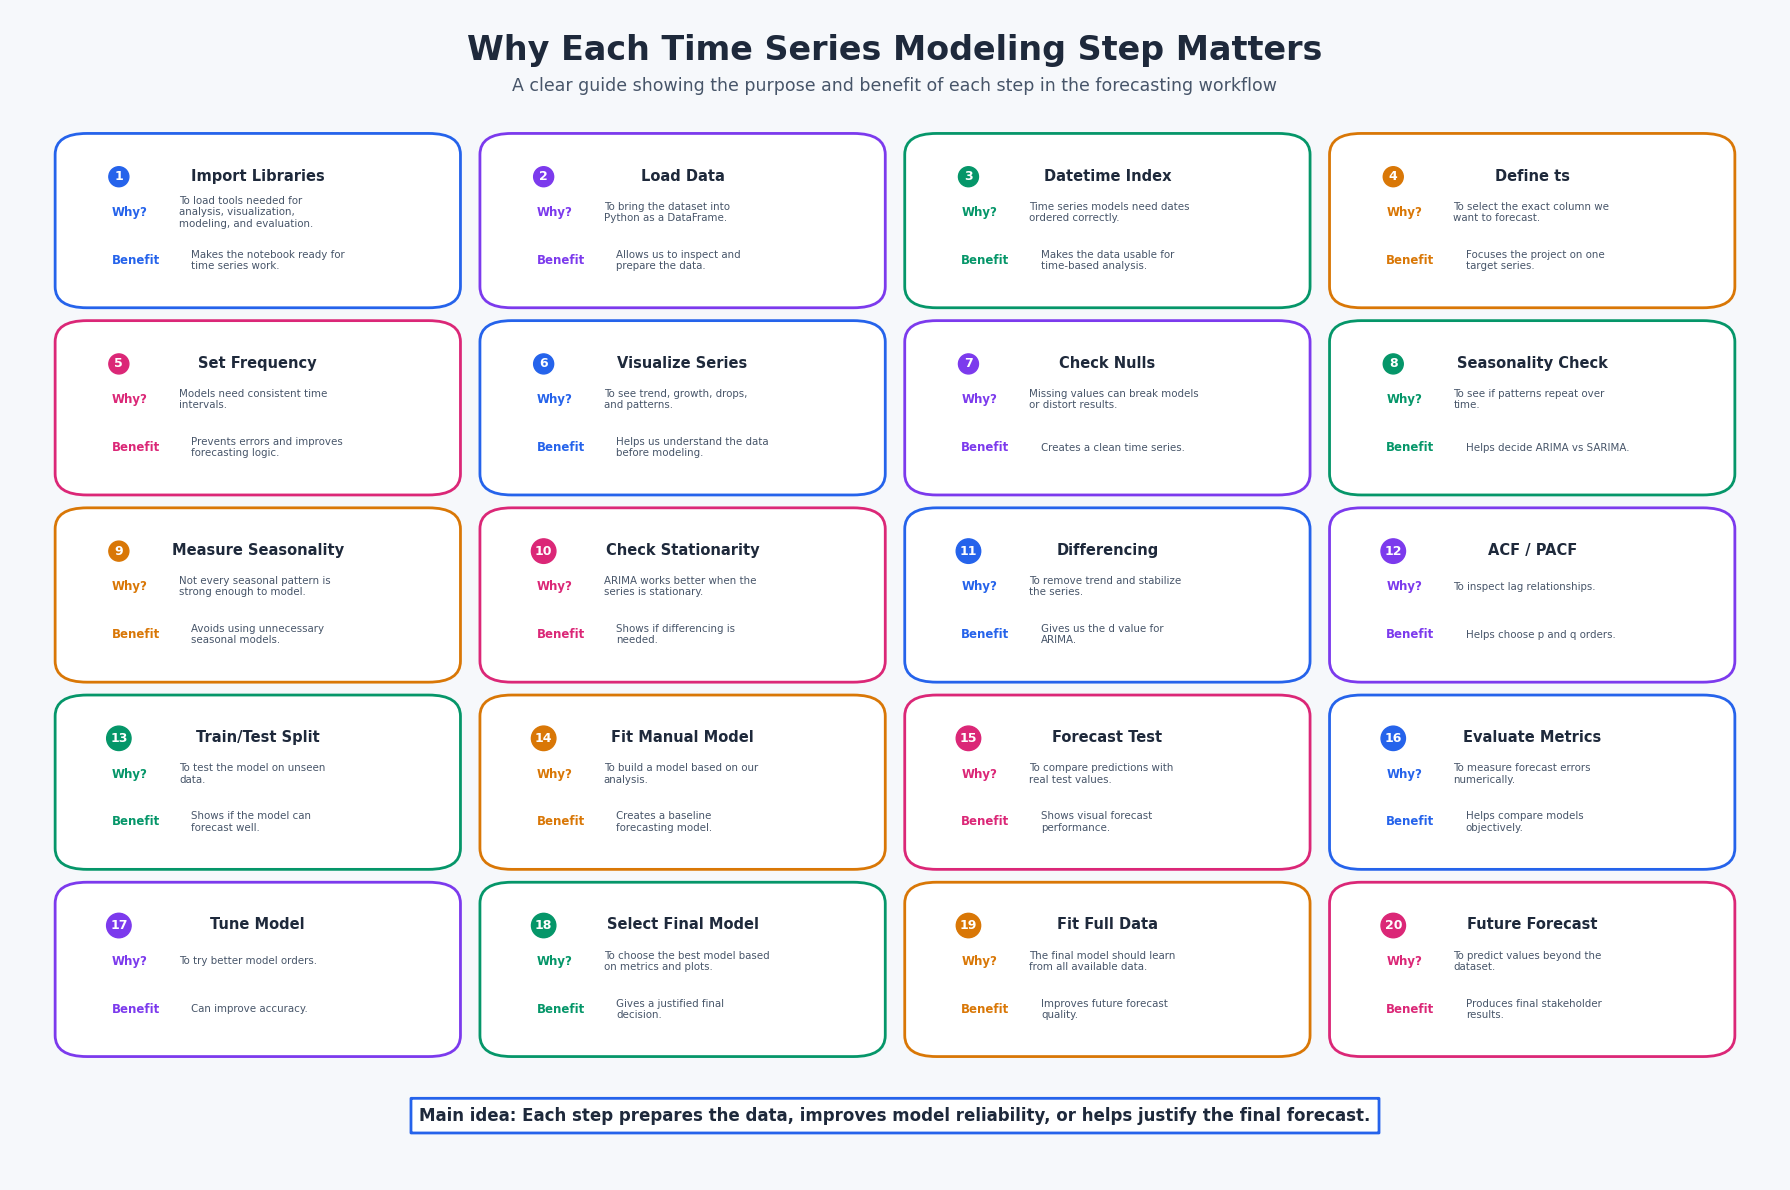

In [27]:
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch
import textwrap

# New professional color palette
BG = "#F6F8FB"
DARK = "#1E293B"
BLUE = "#2563EB"
PURPLE = "#7C3AED"
GREEN = "#059669"
ORANGE = "#D97706"
PINK = "#DB2777"
GRAY = "#475569"
WHITE = "#FFFFFF"

fig, ax = plt.subplots(figsize=(18, 12))
fig.patch.set_facecolor(BG)
ax.set_facecolor(BG)
ax.axis("off")

# Title
ax.text(
    0.5, 0.965,
    "Why Each Time Series Modeling Step Matters",
    ha="center",
    va="center",
    fontsize=24,
    fontweight="bold",
    color=DARK
)

ax.text(
    0.5, 0.935,
    "A clear guide showing the purpose and benefit of each step in the forecasting workflow",
    ha="center",
    va="center",
    fontsize=12.5,
    color=GRAY
)

steps = [
    ("1", "Import Libraries", "Why?", "To load tools needed for analysis, visualization, modeling, and evaluation.", "Benefit", "Makes the notebook ready for time series work."),
    ("2", "Load Data", "Why?", "To bring the dataset into Python as a DataFrame.", "Benefit", "Allows us to inspect and prepare the data."),
    ("3", "Datetime Index", "Why?", "Time series models need dates ordered correctly.", "Benefit", "Makes the data usable for time-based analysis."),
    ("4", "Define ts", "Why?", "To select the exact column we want to forecast.", "Benefit", "Focuses the project on one target series."),

    ("5", "Set Frequency", "Why?", "Models need consistent time intervals.", "Benefit", "Prevents errors and improves forecasting logic."),
    ("6", "Visualize Series", "Why?", "To see trend, growth, drops, and patterns.", "Benefit", "Helps us understand the data before modeling."),
    ("7", "Check Nulls", "Why?", "Missing values can break models or distort results.", "Benefit", "Creates a clean time series."),
    ("8", "Seasonality Check", "Why?", "To see if patterns repeat over time.", "Benefit", "Helps decide ARIMA vs SARIMA."),

    ("9", "Measure Seasonality", "Why?", "Not every seasonal pattern is strong enough to model.", "Benefit", "Avoids using unnecessary seasonal models."),
    ("10", "Check Stationarity", "Why?", "ARIMA works better when the series is stationary.", "Benefit", "Shows if differencing is needed."),
    ("11", "Differencing", "Why?", "To remove trend and stabilize the series.", "Benefit", "Gives us the d value for ARIMA."),
    ("12", "ACF / PACF", "Why?", "To inspect lag relationships.", "Benefit", "Helps choose p and q orders."),

    ("13", "Train/Test Split", "Why?", "To test the model on unseen data.", "Benefit", "Shows if the model can forecast well."),
    ("14", "Fit Manual Model", "Why?", "To build a model based on our analysis.", "Benefit", "Creates a baseline forecasting model."),
    ("15", "Forecast Test", "Why?", "To compare predictions with real test values.", "Benefit", "Shows visual forecast performance."),
    ("16", "Evaluate Metrics", "Why?", "To measure forecast errors numerically.", "Benefit", "Helps compare models objectively."),

    ("17", "Tune Model", "Why?", "To try better model orders.", "Benefit", "Can improve accuracy."),
    ("18", "Select Final Model", "Why?", "To choose the best model based on metrics and plots.", "Benefit", "Gives a justified final decision."),
    ("19", "Fit Full Data", "Why?", "The final model should learn from all available data.", "Benefit", "Improves future forecast quality."),
    ("20", "Future Forecast", "Why?", "To predict values beyond the dataset.", "Benefit", "Produces final stakeholder results.")
]

# Layout: 4 columns x 5 rows
x_positions = [0.14, 0.38, 0.62, 0.86]
y_positions = [0.82, 0.66, 0.50, 0.34, 0.18]

positions = []
for y in y_positions:
    for x in x_positions:
        positions.append((x, y))

colors = [BLUE, PURPLE, GREEN, ORANGE, PINK] * 4

def draw_step_card(ax, x, y, num, title, why_label, why_text, benefit_label, benefit_text, color):
    w, h = 0.205, 0.125

    card = FancyBboxPatch(
        (x - w/2, y - h/2),
        w,
        h,
        boxstyle="round,pad=0.012,rounding_size=0.018",
        linewidth=2,
        edgecolor=color,
        facecolor=WHITE
    )
    ax.add_patch(card)

    # Number circle
    ax.text(
        x - w/2 + 0.024,
        y + h/2 - 0.025,
        num,
        ha="center",
        va="center",
        fontsize=9,
        fontweight="bold",
        color=WHITE,
        bbox=dict(boxstyle="circle,pad=0.28", facecolor=color, edgecolor=color)
    )

    # Title
    ax.text(
        x,
        y + 0.038,
        title,
        ha="center",
        va="center",
        fontsize=10.5,
        fontweight="bold",
        color=DARK
    )

    # Why
    ax.text(
        x - w/2 + 0.02,
        y + 0.007,
        why_label,
        ha="left",
        va="center",
        fontsize=8.5,
        fontweight="bold",
        color=color
    )

    ax.text(
        x - w/2 + 0.058,
        y + 0.007,
        textwrap.fill(why_text, width=31),
        ha="left",
        va="center",
        fontsize=7.4,
        color=GRAY,
        linespacing=1.15
    )

    # Benefit
    ax.text(
        x - w/2 + 0.02,
        y - 0.034,
        benefit_label,
        ha="left",
        va="center",
        fontsize=8.5,
        fontweight="bold",
        color=color
    )

    ax.text(
        x - w/2 + 0.065,
        y - 0.034,
        textwrap.fill(benefit_text, width=29),
        ha="left",
        va="center",
        fontsize=7.4,
        color=GRAY,
        linespacing=1.15
    )

# Draw cards
for i, step in enumerate(steps):
    x, y = positions[i]
    draw_step_card(ax, x, y, *step, colors[i])

# Footer
footer = "Main idea: Each step prepares the data, improves model reliability, or helps justify the final forecast."

ax.text(
    0.5, 0.055,
    footer,
    ha="center",
    va="center",
    fontsize=12,
    fontweight="bold",
    color=DARK,
    bbox=dict(
        boxstyle="round,pad=0.5,rounding_size=0.02",
        facecolor=WHITE,
        edgecolor=BLUE,
        linewidth=2
    )
)

plt.tight_layout()
plt.show()

fig.savefig("time_series_steps_why_benefit.png", dpi=200, bbox_inches="tight", facecolor=BG)